# Feature selection — `unified_schema_<ticker>`

Reads the `pool__*` tables of one ticker's unified schema, joins them on the keys
they share, and ranks every feature against one target.

This run: **`unified_schema_vcb.pool__basic` ⋈ `pool__targets`**, target
**`return_5day`**.

## What the pieces are

| | |
|---|---|
| [`unified_reader.py`](unified_reader.py) | connect, introspect, read with the right dtypes, join on `(exchange, ticker, date)` ∩ |
| [`selector.py`](selector.py) | six rankers → ensemble → correlation prune → walk-forward validation |
| [`gpu.py`](gpu.py) | the CUDA paths, and which steps do not have one |
| [`plots.py`](plots.py) | the figures, one palette applied by the job each colour does |

Nothing here is notebook-specific — the same three imports script the same run
for another ticker, another pool set or another target.

## ⚠️ Two things that decide whether the output means anything

**1. The label looks 5 days forward, so the cross-validation is purged.**
`return_5day` at day `t` is computed from the close at `t+5`. A random K-fold puts
`t+1` in train and `t` in test, and the model reads its own answer — the usual way
a feature-selection notebook reports an R² of 0.4 on a series that is mostly
noise. Every fit below uses `PurgedWalkForward`: expanding window, date order,
with the `horizon` training rows immediately before each test block dropped.

**2. `pool__basic` holds price LEVELS, and a level is a proxy for the date.**
`open`/`high`/`low`/`close_raw`/`close_adjust` rise over seventeen years, so a tree
can use them to identify the era instead of predicting the return. They are
included by default because they are part of the pool as asked — but see
`EXCLUDE_PRICE_LEVELS` below and the closing section, which measures what happens
when they go.

## ⚠️ And one about the GPU

Everything that has a CUDA path uses it: all five tree-based rankers, both
Spearman passes, the stability sweep and the walk-forward validation. Two steps
have no GPU path — `mutual_info` (sklearn's kNN estimator) and `lasso` (cuML is
Linux-only) — and swapping in a different estimator to win a benchmark would
change what the column *means*, so they stay on the host.

**`DEVICE` can change the selected feature set, and the cause is `SUBSAMPLE` /
`COLSAMPLE_BYTREE`.** The two devices draw different random rows and columns from
the same `random_state`, so 4,189 of 8,280 tree nodes end up splitting on a
different feature. Set both to 1.0 and `cuda` and `cpu` agree exactly (identical
kept set, identical fold ICs); leave them at 0.8 for the regularisation and pin
`DEVICE` instead. It is *not* the histogram binning — `gpu.py` §1 has the
elimination table.

## Imports & theme

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import pandas as pd

from feature_selection import gpu, plots
from feature_selection.selector import FeatureSelector
from feature_selection.unified_reader import UnifiedSchemaReader

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
plots.use_theme()

available, why = gpu.cuda_available()
print(f"CUDA usable: {available}" + (f" — {why}" if why else ""))

CUDA usable: True


## Parameters

`POOLS` is the whole run plan. Adding `pool__ta` / `pool__macro` / `pool__calendar`
here is all it takes once those assets exist — the reader joins whatever it is
handed on whatever keys those tables share.

In [2]:
TICKER = "VCB"
POOLS = ["pool__basic", "pool__targets"]
TARGET = "return_5day"
HORIZON = 5              # trading days the label looks forward; sets the CV purge gap

MAX_FEATURES = 15        # cap on the kept set, applied AFTER the redundancy prune
CORR_THRESHOLD = 0.9     # |Spearman| above which the lower-ranked of a pair is dropped
N_SPLITS = 5             # walk-forward folds, used for both stability and validation
MIN_TRAIN = 500          # rows in the first fold's training window

# "auto" | "cuda" | "cpu". ⚠️ See the header: this changes the ANSWER, not just the
# speed. "auto" uses the GPU once the pool is at least gpu.AUTO_CUDA_MIN_FEATURES
# wide, because a 27-column pool measured 21.2 s on the GPU against 12.3 s on the
# host — too little work per kernel launch. "cuda" forces it everywhere possible.
DEVICE = "auto"

# ⚠️ XGBoost's stochastic regularisation, and the ONLY reason a cuda run and a cpu
# run disagree: the two devices draw different random rows/columns from the same
# seed. Set both to 1.0 and the devices produce bit-identical trees and an
# identical kept set — at the cost of the regularisation. Evidence in gpu.py §1.
SUBSAMPLE = 0.8
COLSAMPLE_BYTREE = 0.8

# Identity and the GICS taxonomy are constant for a single ticker. They are
# non-numeric so they would be skipped anyway; naming them makes the intent
# explicit rather than incidental.
IDENTITY = ["exchange", "ticker"]
GICS = [
    "sector", "sector_code", "industry_group", "industry_group_code",
    "industry", "industry_code", "sub_industry", "sub_industry_code",
]

# ⚠️ See the header. Set True to re-run without the raw price levels and compare.
EXCLUDE_PRICE_LEVELS = False
PRICE_LEVELS = ["open", "high", "low", "close_raw", "close_adjust"]

EXCLUDE = IDENTITY + GICS + (PRICE_LEVELS if EXCLUDE_PRICE_LEVELS else [])

## Connect & look at the schema

`overview()` is the orientation table. Read the `key_columns` column before
anything else: `pool__basic` is keyed `(exchange, ticker, date)` and `pool__targets`
by `date` alone — a one-company label table has nowhere to put a ticker. That is
what decides the join key in the next cell.

In [3]:
reader = UnifiedSchemaReader(TICKER).connect()
overview = reader.overview()
overview

,table,rows,columns,key_columns,first_date,last_date
0,pool__basic,4235,38,"exchange, ticker, date",2009-06-30,2026-06-25
1,pool__targets,4235,2,date,2009-06-30,2026-06-25


## Join the pools

The join key is the **intersection** of `(exchange, ticker, date)` present in both
frames, and `date` must be in it. Every merge is validated one-to-one on both
sides first: a duplicated key would turn a 4,235-row panel into a longer one that
still looks like a panel, and the selection would then be fitting on repeats.

`join_log` is the record of what was actually used — read it rather than assuming
`ticker` took part.

In [4]:
panel = reader.join(POOLS)
reader.close()

print(f"panel: {panel.shape[0]:,} rows x {panel.shape[1]} columns  "
      f"({panel['date'].min():%Y-%m-%d} -> {panel['date'].max():%Y-%m-%d})")
join_log = pd.DataFrame(reader.join_log)
join_log

panel: 4,235 rows x 39 columns  (2009-06-30 -> 2026-06-25)


,table,join_keys,how,rows_before,rows_after,columns_added,duplicate_columns_dropped
0,pool__targets,date,inner,4235,4235,1,


## The label

The last `HORIZON` rows are NULL by construction — their future has not happened
yet. The `pool__targets` asset keeps them so the tables still join; the selector
drops them before any fit.

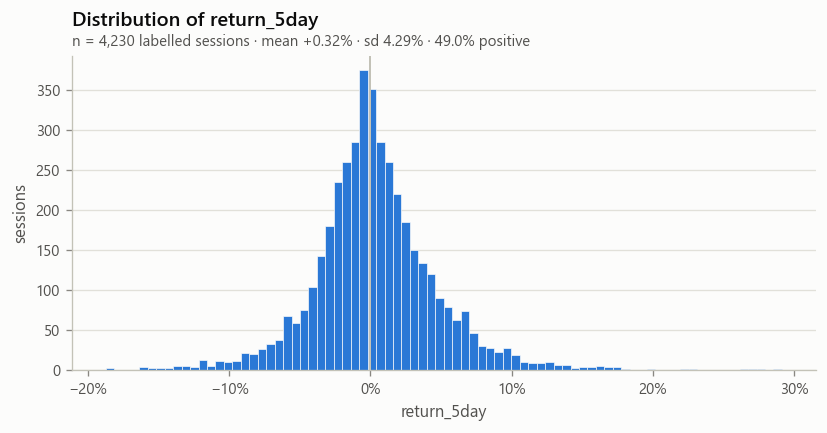

5 unlabelled rows at the tail (expected 5): ['2026-06-19', '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25']


In [5]:
plots.plot_target_distribution(panel[TARGET], TARGET)
plt.show()

print(f"{panel[TARGET].isna().sum()} unlabelled rows at the tail "
      f"(expected {HORIZON}): "
      f"{panel.loc[panel[TARGET].isna(), 'date'].dt.strftime('%Y-%m-%d').tolist()}")

## Run the selection

Six rankers, deliberately chosen so no single model's bias decides the answer:

| method | sees | blind to |
|---|---|---|
| `spearman` | monotone rank association | interactions, non-monotone shapes |
| `mutual_info` | any dependence | direction |
| `xgb_gain` | interactions, thresholds | correlated features split credit arbitrarily |
| `xgb_shap` | the same, attributed per sample | the same, less arbitrarily |
| `lasso` | linear signal, redundancy already priced in | non-linearity |
| `permutation` | **out-of-sample** contribution | features the model never used |

`permutation` is the only one measured out of sample, and it is the one to believe
when it disagrees. The ensemble is a **rank** average, not a score average — one
method with a long-tailed raw scale would otherwise decide the blend alone.

In [6]:
selector = FeatureSelector(
    panel=panel,
    target=TARGET,
    exclude=EXCLUDE,
    max_features=MAX_FEATURES,
    corr_threshold=CORR_THRESHOLD,
    horizon=HORIZON,
    n_splits=N_SPLITS,
    min_train=MIN_TRAIN,
    device=DEVICE,
    subsample=SUBSAMPLE,
    colsample_bytree=COLSAMPLE_BYTREE,
)
result = selector.run()

print(f"{result.n_rows:,} labelled rows, {len(result.features)} candidate features")
print(f"device: {result.device} — {gpu.device_report()['reason']}")
print(f"kept {len(result.kept)}: {result.kept}")
if result.dropped_constant:
    print(f"never scored (constant / all-NaN): {result.dropped_constant}")
if result.dead_methods:
    print(f"\n! separated nothing, contributed a constant to the blend: "
          f"{result.dead_methods}")
    print("  (LASSO zeroing every coefficient is a finding, not a bug: no linear "
          "signal survives cross-validated shrinkage on this pool.)")

4,230 labelled rows, 27 candidate features
device: cpu — auto — 27 features is under the 200-feature crossover, where the host is faster; pass device='cuda' to force the GPU
kept 15: ['low', 'foreign_room_left', 'close_adjust', 'foreign_sell_value', 'foreign_buy_value', 'foreign_net_volume', 'foreign_own', 'prop_buy_vol', 'n_sell_orders', 'buy_order_vol', 'prop_sell_val', 'avg_vol_per_buy_order', 'value_negotiated', 'avg_vol_per_sell_order', 'volume_negotiated']

! separated nothing, contributed a constant to the blend: ['lasso']
  (LASSO zeroing every coefficient is a finding, not a bug: no linear signal survives cross-validated shrinkage on this pool.)


### Where the time went

`device` per row is what makes "this uses the GPU" checkable instead of a claim.
The two `cpu` rows are `mutual_info` and `lasso` — the two rankers whose estimator
has no GPU implementation at all.

In [7]:
timings = result.timing_table.round(3)
timings

,step,seconds,device,share
0,validation,4.409,cpu,0.385
1,stability,2.994,cpu,0.261
2,permutation,2.632,cpu,0.230
3,lasso,0.530,cpu,0.046
4,mutual_info,0.456,cpu,0.040
5,xgb gain + shap,0.409,cpu,0.036
6,feature corr matrix,0.012,cpu,0.001
7,spearman vs target,0.011,cpu,0.001


## The ranking

`ensemble` is a **mean rank**, so lower is better and the table is sorted
ascending. `dropped_for` names the feature a row was found redundant against —
"dropped 12 features" is not reviewable, `volume_matched ≈ buy_order_vol` is.

In [8]:
ranking = result.ranking.round(3)
ranking

,ensemble,kept,dropped_for,spearman,mutual_info,xgb_gain,xgb_shap,lasso,permutation
low,3.833,True,,0.278,0.641,0.946,0.324,0.0,1.000
close_raw,4.333,False,low,0.294,0.662,0.846,0.584,0.0,0.062
foreign_room_left,5.167,True,,0.420,0.422,0.654,0.272,0.0,0.104
close_adjust,5.667,True,,0.205,1.000,0.714,1.000,0.0,0.000
high,7.333,False,low,0.277,0.594,0.473,0.095,0.0,0.871
open,7.667,False,low,0.280,0.558,0.407,0.114,0.0,0.573
foreign_sell_value,8.333,True,,0.925,0.134,0.480,0.114,0.0,0.000
foreign_buy_value,8.500,True,,0.477,0.032,0.565,0.169,0.0,0.100
foreign_net_volume,9.333,True,,0.554,0.106,0.447,0.137,0.0,0.000
foreign_own,9.333,True,,0.000,0.411,0.738,0.250,0.0,0.000


## Where the methods agree, and where they don't

Read **across** a row, not down a column: each column is min-max normalised to
0-1, so the numbers are comparable within a method and not between them. A row
dark all the way across is a feature every method likes; a row dark in one column
only is that method's inductive bias talking.

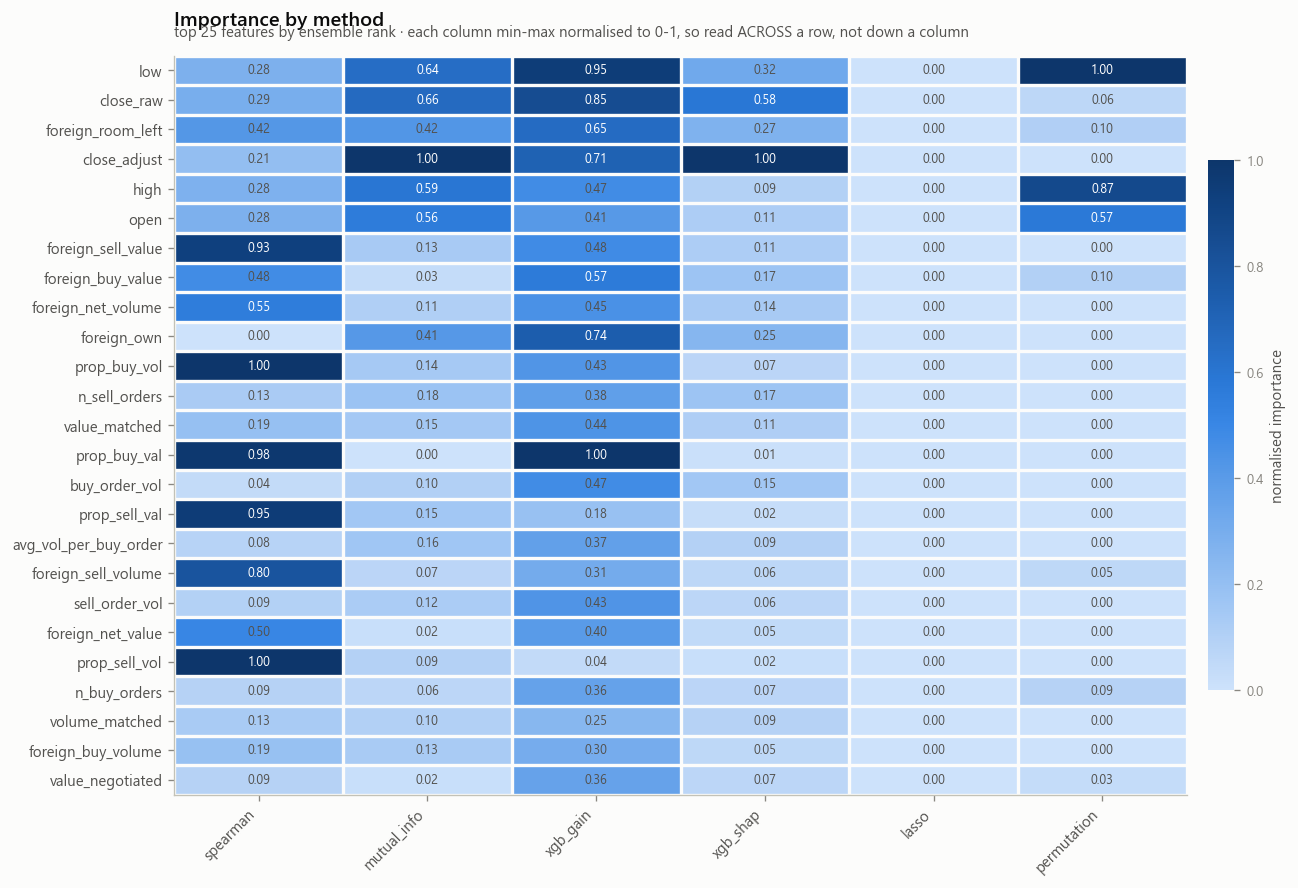

In [9]:
plots.plot_method_heatmap(result.scores, top=25)
plt.show()

## Association with the target

Signed, so the encoding diverges about a neutral zero. **Read the axis scale
before the ranking** — on a forward equity return the whole chart usually lives
inside ±0.1, and a ranking of near-zero numbers is still a ranking of near-zero
numbers.

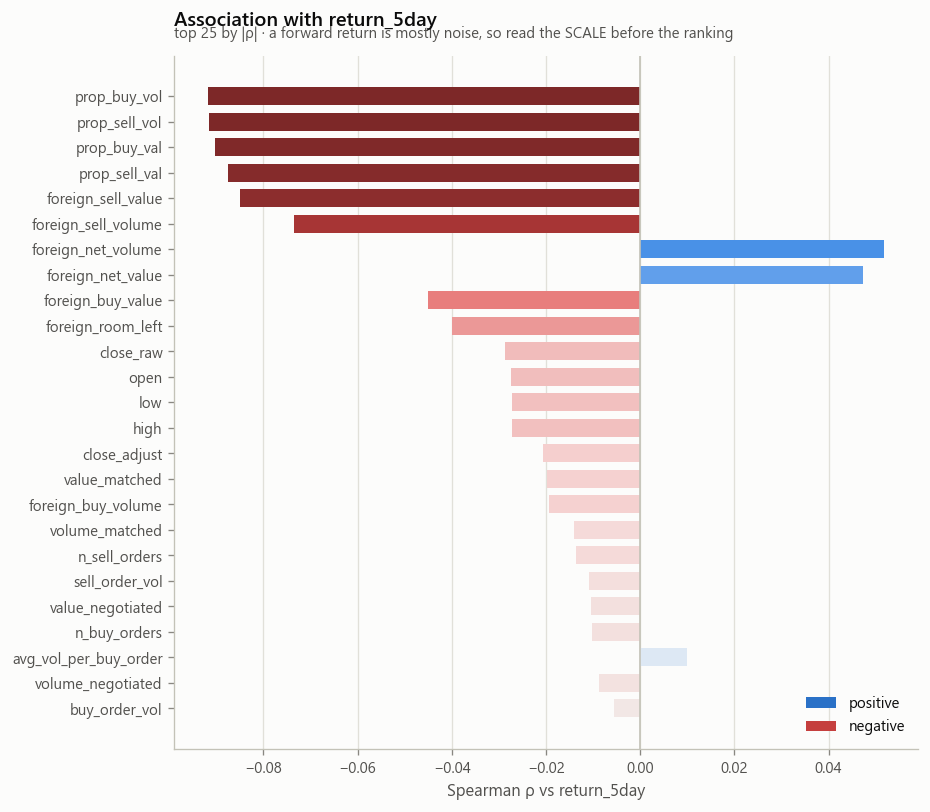

In [10]:
plots.plot_target_correlation(result.target_corr, TARGET, top=25)
plt.show()

## Redundancy

Ordered by ensemble rank, so the dark off-diagonal blocks are exactly what the
prune is about to remove. `pool__basic` is full of them by construction: OHLC are
four views of one price, and every flow measure appears as both a volume and a
value.

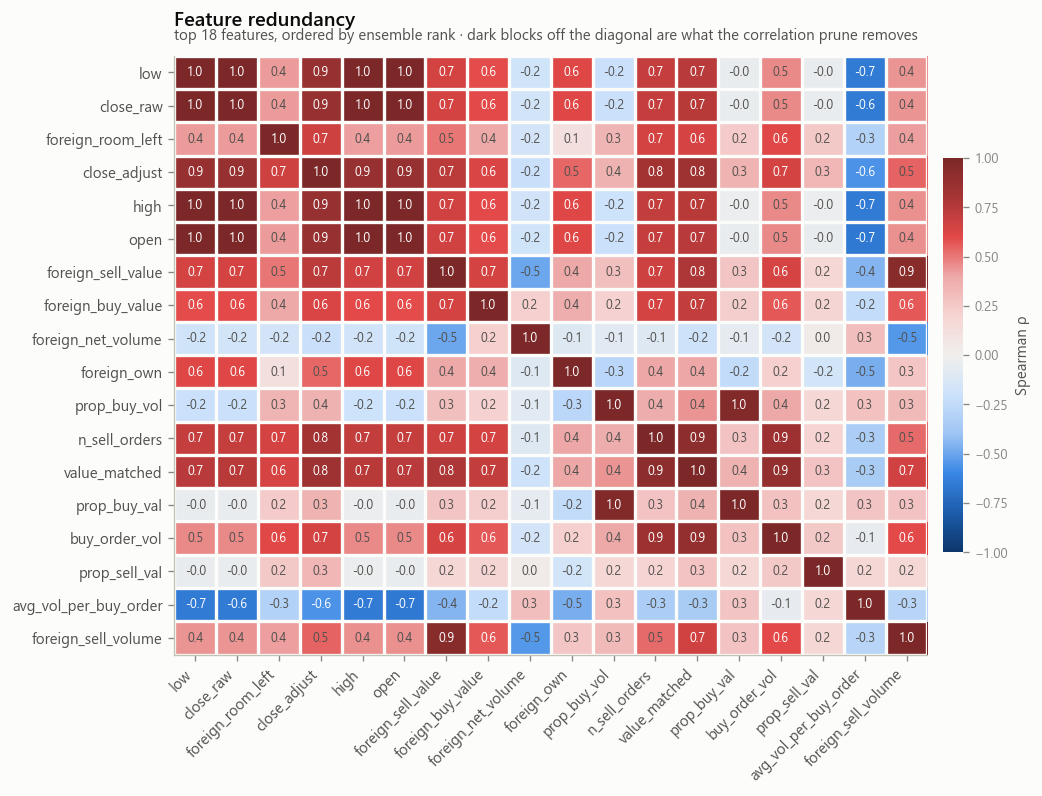

,dropped,duplicates,spearman
0,open,low,1.000
1,close_raw,low,0.999
2,high,low,0.999
3,prop_buy_val,prop_buy_vol,0.973
4,foreign_net_value,foreign_net_volume,0.972
5,prop_sell_vol,prop_sell_val,0.964
6,sell_order_vol,buy_order_vol,0.949
7,volume_matched,buy_order_vol,0.947
8,foreign_sell_volume,foreign_sell_value,0.941
9,foreign_buy_volume,foreign_buy_value,0.925


In [11]:
plots.plot_correlation_heatmap(result.corr, top=18)
plt.show()

redundancy = pd.DataFrame(
    [{"dropped": k, "duplicates": v,
      "spearman": round(float(result.corr.loc[k, v]), 3)}
     for k, v in result.dropped_correlated.items()]
).sort_values("spearman", key=abs, ascending=False).reset_index(drop=True)
redundancy

## Is it stable, or is it one regime?

Each column is one expanding training window. A feature ranked 2nd in the first
fold and 40th since is not a feature, it is a regime — and on a seventeen-year
single-stock panel that is the failure mode to watch for, not overfitting to
noise.

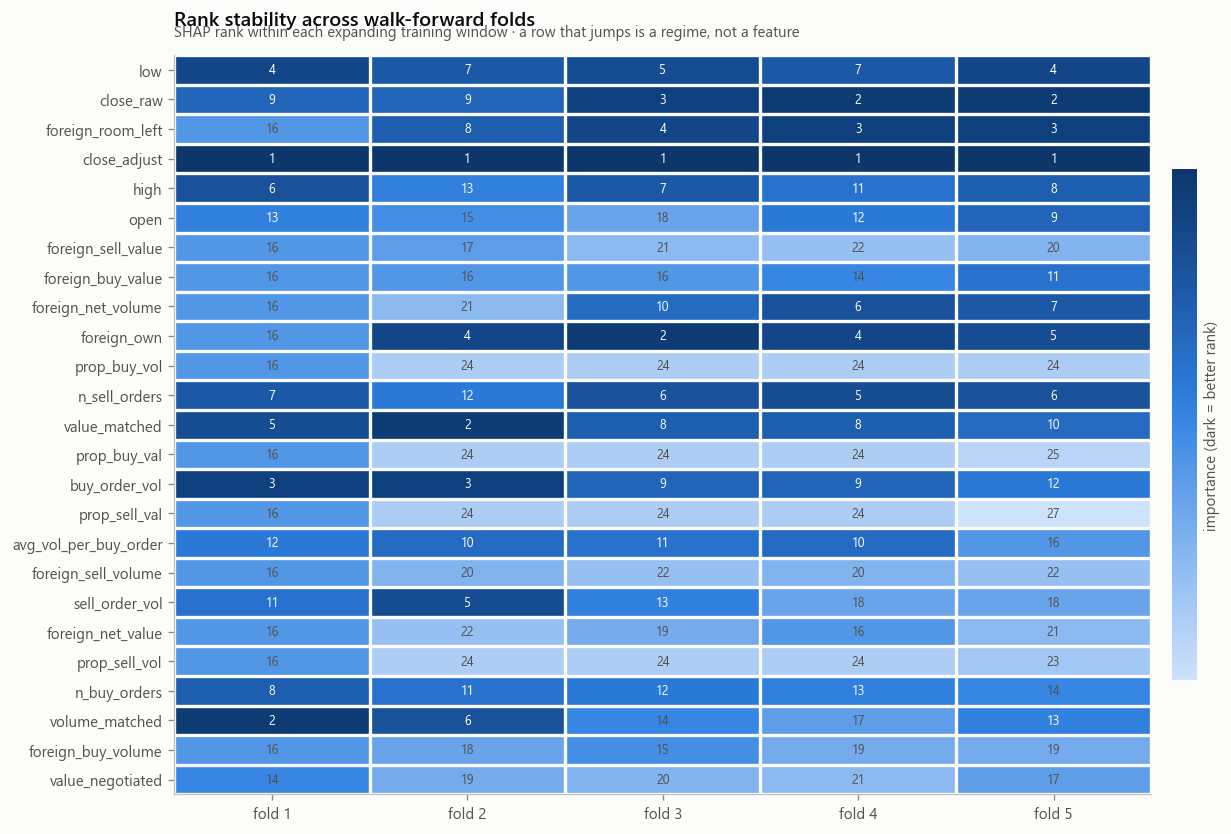

In [12]:
plots.plot_stability_heatmap(result.stability, top=25)
plt.show()

## The kept set

Pruned features stay on the chart rather than vanishing, because "why is
`value_matched` not in there" is the first question anyone asks of a selection.

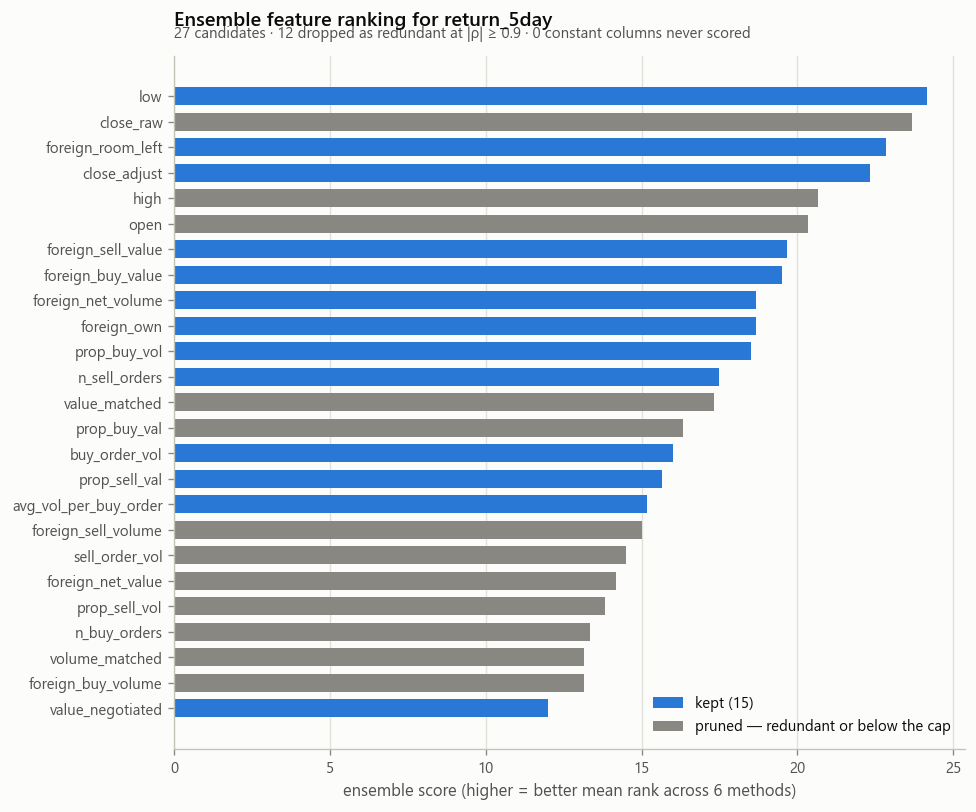

In [13]:
plots.plot_ensemble_ranking(result, top=25)
plt.show()

## Does the selection generalise?

Out-of-sample, per fold, never averaged into one number: with a 5-day overlapping
label the fold-to-fold spread **is** the uncertainty, and a mean would present
noise as a result.

`ic` (Spearman rank correlation of prediction against realised return) is the
metric to read. `r2` is reported and will be deeply negative — that is the honest
answer for a level-scale forecast of a near-noise series, not a bug; a model can
rank days correctly while being badly calibrated on magnitude.

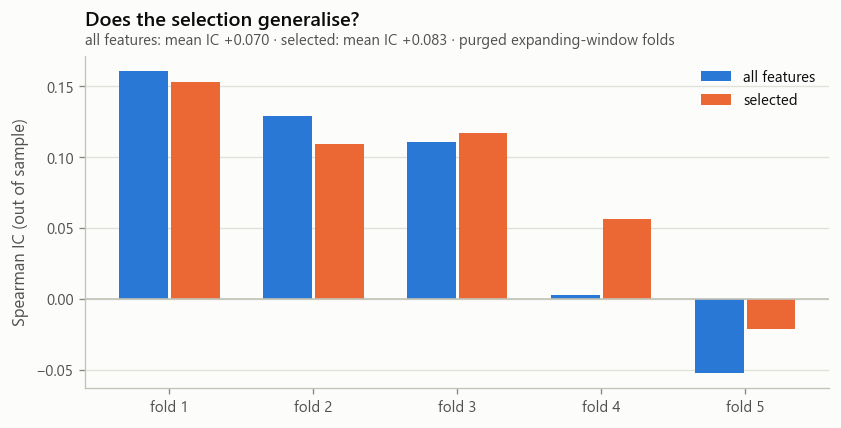

ic                              r2                         hit_rate                        
                mean     std     min     max    mean     std     min     max     mean     std     min     max
feature_set                                                                                                  
all features  0.0703  0.0907 -0.0524  0.1610 -1.6125  1.1075 -2.7797 -0.3782   0.4937  0.0432  0.4416  0.5517
selected      0.0830  0.0676 -0.0212  0.1529 -2.2311  2.3764 -6.0909 -0.2998   0.4999  0.0452  0.4376  0.5597

In [14]:
plots.plot_validation(result.validation)
plt.show()

summary = (
    result.validation
    .groupby("feature_set")[["ic", "r2", "hit_rate"]]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)
summary

## Reading this run

Fill this in from the output above — the numbers move whenever the pools are
rebuilt. What to look at, in order:

1. **The scale in "Association with the target".** If nothing clears |ρ| ≈ 0.1,
   the honest conclusion is that `pool__basic` alone does not predict the forward
   5-day return, and the ranking below that is ordering noise. That is a result,
   and it is the one the cross-sectional work in
   [`../model/CONTEXT.md`](../model/CONTEXT.md) already points at.
2. **The IC by fold.** A positive mean carried by the early folds and negative in
   the last is the signature of a relationship that has decayed — the opposite of
   something to trade.
3. **The price levels.** If `low` / `close_raw` / `close_adjust` top the ranking on
   `permutation` while contributing nothing on `spearman`, the model is using the
   price level to identify the era. Set `EXCLUDE_PRICE_LEVELS = True` at the top,
   re-run, and compare the fold ICs: what survives is what is actually about
   order flow and foreign activity rather than about *when*.

## Extending it

* **Another pool.** Add it to `POOLS`. `pool__ta` is ~900 columns — raise
  `MAX_FEATURES`, and `DEVICE="auto"` will move to the GPU on its own at that
  width. Expect the permutation and stability passes to dominate the runtime
  (memory `project-feature-selection-ta-cost` measured ~6.6 h for the old full
  ensemble on that pool); the redundancy matrix, which used to be the other half
  of the cost, is now 0.5 s.
* **Another ticker.** Change `TICKER`. The schema name is a template and the
  reader validates it as an identifier; nothing else changes.
* **Another target.** `pool__targets` currently holds only `return_5day`. The
  three others the old notebook built (`return_rel_5day`, `direction_5day`,
  `probability_gain_5pct_5day`) are not assets yet — see
  [`../orchestration/CONTEXT.md`](../orchestration/CONTEXT.md) §UNIFIED. For a
  binary target the six rankers need classifier variants; `selector.py` is
  regression-only today and will silently treat 0/1 as a continuous label.